# Лабораторная 7: генерация лиц с помощью GAN

Набор данных: CelebA.

Цели:
1. Подготовить данные: вырезать лица детектором и выровнять их по опорным точкам.
2. Обучить самописный GAN для безусловной генерации лиц.
3. Преобразовать ту же сеть в условную и обучить генерацию по полу.
4. Посчитать FID и IS, показать кривые обучения.
5. Показать, что из одного вектора шума с разными метками получаются разные лица.
6. Обучить Wasserstein GAN и сравнить с обычным.


In [1]:
# %pip install -q torchmetrics torch-fidelity kagglehub opencv-python pandas matplotlib

import urllib.request
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

IMG_SIZE = 64
NZ = 100
BATCH = 128
EPOCHS = 25
EPOCHS_WGAN = 25
EVAL_EVERY = 5
N_EVAL = 2048

ROOT = next((p for p in (Path('.'), Path('lab-7')) if (p / 'lab-7.ipynb').exists()), Path('lab-7')).resolve()
DATA = ROOT / 'data'
RUNS = ROOT / 'runs'
DATA.mkdir(exist_ok=True)
RUNS.mkdir(exist_ok=True)

print('Устройство:', DEVICE, torch.cuda.get_device_name(0) if DEVICE.type == 'cuda' else '')
print('Каталог лабы:', ROOT)


Устройство: cuda NVIDIA GeForce RTX 4060
Каталог лабы: C:\mlcv-itmo\lab-7


## 1. Подготовка данных

Изображения CelebA уже центрированы по лицу, но кадр включает волосы, плечи и фон.
Для GAN важно, чтобы распределение было как можно уже, поэтому лица вырезаем детектором и выравниваем.

Детектор — **YuNet**: он входит в OpenCV, весит 340 КБ и возвращает не только рамку,
но и 5 опорных точек (глаза, нос, углы рта). Точки позволяют сразу сделать выравнивание:
ищем преобразование подобия, переводящее найденные точки в каноническое положение,
и применяем его к изображению. После этого глаза у всех лиц оказываются на одной высоте.


In [2]:
YUNET = DATA / 'face_detection_yunet_2023mar.onnx'
if not YUNET.exists():
    urllib.request.urlretrieve(
        'https://github.com/opencv/opencv_zoo/raw/main/models/face_detection_yunet/'
        'face_detection_yunet_2023mar.onnx', YUNET)

# каноническое положение опорных точек (ArcFace, отмасштабировано под наш размер)
REF_POINTS = np.float32([[38.29, 51.70], [73.53, 51.50], [56.03, 71.74],
                         [41.55, 92.37], [70.73, 92.20]]) * IMG_SIZE / 112


def align_face(img, points, size=IMG_SIZE):
    """Преобразование подобия, переводящее опорные точки лица в каноническое положение."""
    M, _ = cv2.estimateAffinePartial2D(points.reshape(5, 2), REF_POINTS, method=cv2.LMEDS)
    if M is None:
        return None
    return cv2.warpAffine(img, M, (size, size), flags=cv2.INTER_AREA)


def build_dataset(src_dir, attr_csv):
    files = sorted(Path(src_dir).glob('*.jpg'))
    male = pd.read_csv(attr_csv).set_index('image_id')['Male']
    detector = cv2.FaceDetectorYN.create(str(YUNET), '', (178, 218), 0.6, 0.3, 5000)

    faces = np.lib.format.open_memmap(DATA / 'faces.npy', mode='w+', dtype=np.uint8,
                                      shape=(len(files), IMG_SIZE, IMG_SIZE, 3))
    labels = np.zeros(len(files), np.int64)
    kept = 0

    for i, path in enumerate(files):
        img = cv2.imread(str(path))
        if img is None:
            continue
        _, detected = detector.detect(img)
        if detected is None or not len(detected):
            continue
        box = max(detected, key=lambda r: r[2] * r[3])
        face = align_face(img, box[4:14].astype(np.float32))
        if face is None:
            continue
        faces[kept] = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
        labels[kept] = int(male[path.name] == 1)
        kept += 1
        if i % 25000 == 0 and i:
            print(f'  обработано {i}/{len(files)}')

    faces.flush()
    np.save(DATA / 'labels.npy', labels[:kept])
    (DATA / 'count.txt').write_text(str(kept))
    print(f'Лицо найдено на {kept} из {len(files)} изображений ({100 * kept / len(files):.1f}%)')
    return kept


In [3]:
import kagglehub

CELEBA = Path(kagglehub.dataset_download('jessicali9530/celeba-dataset'))

if (DATA / 'count.txt').exists():
    n_faces = int((DATA / 'count.txt').read_text())
    print('Датасет уже собран, пропускаем:', n_faces, 'лиц')
else:
    n_faces = build_dataset(CELEBA / 'img_align_celeba' / 'img_align_celeba',
                            CELEBA / 'list_attr_celeba.csv')

faces = np.load(DATA / 'faces.npy', mmap_mode='r')[:n_faces]
labels = np.load(DATA / 'labels.npy')

print(f'Лиц: {len(faces)}, мужчин {100 * labels.mean():.1f}%, женщин {100 * (1 - labels.mean()):.1f}%')


Датасет уже собран, пропускаем: 202507 лиц
Лиц: 202507, мужчин 41.7%, женщин 58.3%


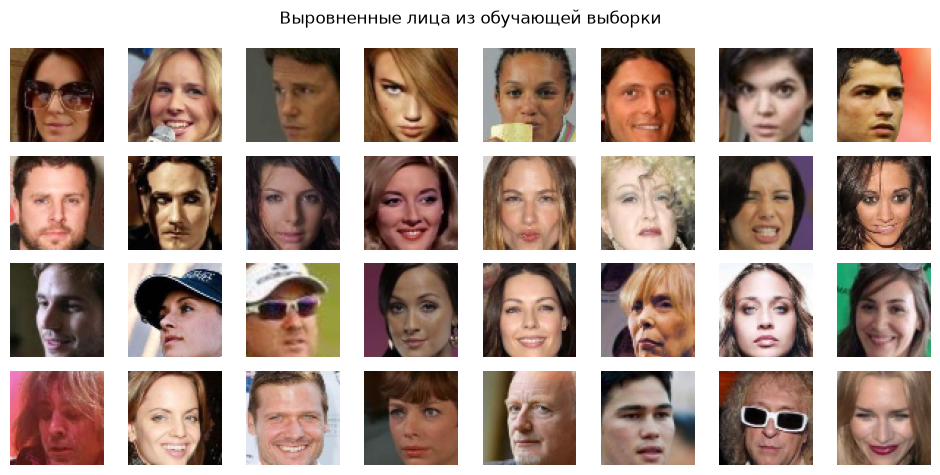

In [4]:
def show_grid(images, title='', nrow=8, size=1.2):
    """images: массив HxWx3 uint8 либо тензор Nx3xHxW в диапазоне [-1, 1]."""
    if torch.is_tensor(images):
        images = ((images.clamp(-1, 1) + 1) * 127.5).byte().permute(0, 2, 3, 1).cpu().numpy()
    ncol = int(np.ceil(len(images) / nrow))
    fig, axes = plt.subplots(ncol, nrow, figsize=(nrow * size, ncol * size), squeeze=False)
    for ax, im in zip(axes.ravel(), images):
        ax.imshow(im)
    for ax in axes.ravel():
        ax.axis('off')
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


show_grid(faces[np.sort(np.random.choice(len(faces), 32, replace=False))],
          'Выровненные лица из обучающей выборки')


## 2. Батчи

Готовые лица лежат на диске одним массивом `uint8`, поэтому обычный `DataLoader` с рабочими
процессами не нужен: батч нарезается срезом, а перевод в `[-1, 1]` и отражение по горизонтали
выполняются уже на устройстве, где идёт обучение. Это и быстрее, и не зависит от способа
запуска процессов в конкретной системе.


In [5]:
def batches(faces, labels, batch=BATCH, shuffle=True, flip=True):
    """Нарезает датасет на батчи и переносит их на устройство в диапазоне [-1, 1]."""
    order = np.random.permutation(len(faces)) if shuffle else np.arange(len(faces))
    for i in range(0, len(order) - batch + 1, batch):
        sel = np.sort(order[i:i + batch])
        x = torch.from_numpy(np.asarray(faces[sel])).to(DEVICE)
        x = x.permute(0, 3, 1, 2).float().div_(127.5).sub_(1.0)
        if flip:
            mask = torch.rand(len(sel), device=DEVICE) < 0.5
            x[mask] = x[mask].flip(-1)
        yield x, torch.from_numpy(labels[sel]).to(DEVICE)


STEPS_PER_EPOCH = len(faces) // BATCH
print(f'Батчей в эпохе: {STEPS_PER_EPOCH}')


Батчей в эпохе: 1582


## 3. Архитектура

Генератор и дискриминатор написаны сами, по схеме DCGAN. Генератор поднимает вектор шума
до изображения транспонированными свёртками, дискриминатор сворачивает изображение до одного числа.

Обе сети принимают параметр `num_classes`. Если он равен нулю — сеть безусловная.
Если задан — та же самая архитектура становится условной: в генераторе метка проходит через
`nn.Embedding` и приклеивается к вектору шума, в дискриминаторе разворачивается в дополнительный
канал изображения. Так оба пункта задания решаются одной сетью, а не двумя разными.

Флаг `wgan` у дискриминатора заменяет BatchNorm на InstanceNorm: в WGAN-GP штраф считается
по каждому примеру отдельно, а BatchNorm смешивает примеры внутри батча и ломает его.


In [6]:
class Generator(nn.Module):
    def __init__(self, nz=NZ, ngf=64, img_size=IMG_SIZE, num_classes=0, embed_dim=50):
        super().__init__()
        self.num_classes = num_classes
        if num_classes:
            self.embed = nn.Embedding(num_classes, embed_dim)

        in_ch = nz + (embed_dim if num_classes else 0)
        blocks = [nn.ConvTranspose2d(in_ch, ngf * 8, 4, 1, 0, bias=False),
                  nn.BatchNorm2d(ngf * 8), nn.ReLU(True)]
        ch, cur = ngf * 8, 4
        while cur * 2 < img_size:
            blocks += [nn.ConvTranspose2d(ch, ch // 2, 4, 2, 1, bias=False),
                       nn.BatchNorm2d(ch // 2), nn.ReLU(True)]
            ch, cur = ch // 2, cur * 2
        blocks += [nn.ConvTranspose2d(ch, 3, 4, 2, 1, bias=False), nn.Tanh()]
        self.net = nn.Sequential(*blocks)

    def forward(self, z, labels=None):
        if self.num_classes:
            z = torch.cat([z, self.embed(labels)[:, :, None, None]], dim=1)
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self, ndf=64, img_size=IMG_SIZE, num_classes=0, wgan=False):
        super().__init__()
        self.num_classes, self.img_size = num_classes, img_size
        if num_classes:
            self.embed = nn.Embedding(num_classes, img_size * img_size)

        norm = (lambda c: nn.InstanceNorm2d(c, affine=True)) if wgan else nn.BatchNorm2d
        in_ch = 3 + (1 if num_classes else 0)
        blocks = [nn.Conv2d(in_ch, ndf, 4, 2, 1, bias=False), nn.LeakyReLU(0.2, True)]
        ch, cur = ndf, img_size // 2
        while cur > 4:
            blocks += [nn.Conv2d(ch, ch * 2, 4, 2, 1, bias=False),
                       norm(ch * 2), nn.LeakyReLU(0.2, True)]
            ch, cur = ch * 2, cur // 2
        blocks += [nn.Conv2d(ch, 1, 4, 1, 0, bias=False)]
        self.net = nn.Sequential(*blocks)

    def forward(self, x, labels=None):
        if self.num_classes:
            x = torch.cat([x, self.embed(labels).view(-1, 1, self.img_size, self.img_size)], dim=1)
        return self.net(x).view(-1)


def init_weights(m):
    """Инициализация из статьи DCGAN."""
    if 'Conv' in m.__class__.__name__:
        nn.init.normal_(m.weight, 0.0, 0.02)
    elif 'BatchNorm' in m.__class__.__name__:
        nn.init.normal_(m.weight, 1.0, 0.02)
        nn.init.zeros_(m.bias)


print(f'Генератор: {sum(p.numel() for p in Generator().parameters()) / 1e6:.2f}M параметров')
print(f'Дискриминатор: {sum(p.numel() for p in Discriminator().parameters()) / 1e6:.2f}M параметров')


Генератор: 3.58M параметров
Дискриминатор: 2.77M параметров


## 4. Метрики

**FID** сравнивает распределения признаков InceptionV3 у настоящих и сгенерированных изображений:
считает среднее и ковариацию для каждого набора и меряет расстояние между двумя гауссианами.
Чем меньше, тем ближе генерация к реальным данным.

**IS** оценивает только сгенерированные изображения: хорошо, когда классификатор уверен в классе
каждой картинки по отдельности, но классы по всей выборке разнообразны. Для лиц метрика слабая —
ImageNet-классификатор не различает лица по классам, поэтому IS здесь почти не меняется.
Считаем её, потому что требует задание, но опираться стоит на FID.


In [7]:
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore


@torch.no_grad()
def generate(G, n, labels=None, batch=256):
    """Генерация n изображений в диапазоне [-1, 1]."""
    G.eval()
    out = []
    for i in range(0, n, batch):
        k = min(batch, n - i)
        z = torch.randn(k, NZ, 1, 1, device=DEVICE)
        y = labels[i:i + k] if labels is not None else (
            torch.randint(0, G.num_classes, (k,), device=DEVICE) if G.num_classes else None)
        out.append(G(z, y).cpu())
    G.train()
    return torch.cat(out)


def to_uint8(x):
    return ((x.clamp(-1, 1) + 1) * 127.5).byte()


REAL_FOR_FID = torch.from_numpy(
    np.asarray(faces[np.sort(np.random.choice(len(faces), N_EVAL, replace=False))])
).permute(0, 3, 1, 2).contiguous()


def evaluate(G, n=N_EVAL):
    """Возвращает (FID, IS) по n сгенерированным изображениям."""
    fid = FrechetInceptionDistance(feature=2048).to(DEVICE)
    iscore = InceptionScore().to(DEVICE)
    for i in range(0, n, 256):
        fid.update(REAL_FOR_FID[i:i + 256].to(DEVICE), real=True)
    fake = to_uint8(generate(G, n))
    for i in range(0, n, 256):
        chunk = fake[i:i + 256].to(DEVICE)
        fid.update(chunk, real=False)
        iscore.update(chunk)
    return float(fid.compute()), float(iscore.compute()[0])


## 5. Цикл обучения

Обучение GAN — минимаксная игра: дискриминатор учится отличать настоящие изображения
от сгенерированных, генератор — обманывать дискриминатор. Шаги чередуются.

Один и тот же цикл обслуживает все три модели, режим переключается параметром `mode`:

- `bce` — классический GAN, обе сети оптимизируют бинарную кросс-энтропию;
- `wgan_gp` — Wasserstein GAN: критик оценивает расстояние Вассерштейна и обновляется
  чаще генератора, а вместо ограничения весов используется штраф за норму градиента.


In [8]:
def gradient_penalty(D, real, fake, labels):
    """Норма градиента критика на отрезке между настоящим и сгенерированным должна равняться 1."""
    eps = torch.rand(real.size(0), 1, 1, 1, device=DEVICE)
    mixed = (eps * real + (1 - eps) * fake).requires_grad_(True)
    grad = torch.autograd.grad(D(mixed, labels).sum(), mixed, create_graph=True)[0]
    return ((grad.reshape(real.size(0), -1).norm(2, dim=1) - 1) ** 2).mean()


def train_gan(G, D, epochs, mode='bce', lr=2e-4, n_critic=5, gp_weight=10.0):
    if mode == 'bce':
        optG = torch.optim.Adam(G.parameters(), lr, betas=(0.5, 0.999))
        optD = torch.optim.Adam(D.parameters(), lr, betas=(0.5, 0.999))
        bce = nn.BCEWithLogitsLoss()
    else:
        optG = torch.optim.Adam(G.parameters(), lr, betas=(0.0, 0.9))
        optD = torch.optim.Adam(D.parameters(), lr, betas=(0.0, 0.9))

    history = {'loss_g': [], 'loss_d': [], 'eval_epoch': [], 'fid': [], 'is': []}
    step = 0

    for epoch in range(1, epochs + 1):
        sum_g = sum_d = n_g = n_d = 0

        for real, y in batches(faces, labels):
            bs = real.size(0)
            y_in = y if G.num_classes else None
            fake = G(torch.randn(bs, NZ, 1, 1, device=DEVICE), y_in)

            if mode == 'bce':
                loss_d = (bce(D(real, y_in), torch.ones(bs, device=DEVICE))
                          + bce(D(fake.detach(), y_in), torch.zeros(bs, device=DEVICE)))
            else:
                loss_d = (D(fake.detach(), y_in).mean() - D(real, y_in).mean()
                          + gp_weight * gradient_penalty(D, real, fake.detach(), y_in))
            optD.zero_grad(set_to_none=True)
            loss_d.backward()
            optD.step()
            sum_d += loss_d.item()
            n_d += 1
            step += 1

            if mode == 'bce' or step % n_critic == 0:
                if mode == 'bce':
                    loss_g = bce(D(fake, y_in), torch.ones(bs, device=DEVICE))
                else:
                    z = torch.randn(bs, NZ, 1, 1, device=DEVICE)
                    loss_g = -D(G(z, y_in), y_in).mean()
                optG.zero_grad(set_to_none=True)
                loss_g.backward()
                optG.step()
                sum_g += loss_g.item()
                n_g += 1

        history['loss_d'].append(sum_d / max(n_d, 1))
        history['loss_g'].append(sum_g / max(n_g, 1))
        line = (f'эпоха {epoch:3d}/{epochs}  loss_D={history["loss_d"][-1]:7.3f}'
                f'  loss_G={history["loss_g"][-1]:7.3f}')

        if epoch % EVAL_EVERY == 0 or epoch == epochs:
            fid, is_score = evaluate(G)
            history['eval_epoch'].append(epoch)
            history['fid'].append(fid)
            history['is'].append(is_score)
            line += f'  FID={fid:6.1f}  IS={is_score:.2f}'

        print(line, flush=True)

    return history


def run_or_load(name, num_classes, epochs, mode='bce'):
    """Обучает модель либо подхватывает уже обученную, чтобы повторный прогон не считал заново."""
    path = RUNS / f'{name}.pt'
    G = Generator(num_classes=num_classes).to(DEVICE)
    G.apply(init_weights)

    if path.exists():
        state = torch.load(path, map_location=DEVICE)
        G.load_state_dict(state['G'])
        print(f'Найдены готовые веса {path.name}, обучение пропускаем')
        return G, state['history']

    D = Discriminator(num_classes=num_classes, wgan=(mode == 'wgan_gp')).to(DEVICE)
    D.apply(init_weights)
    history = train_gan(G, D, epochs, mode=mode)
    torch.save({'G': G.state_dict(), 'history': history}, path)
    return G, history


## 6. Безусловная генерация


эпоха   1/25  loss_D=  0.635  loss_G=  5.778


эпоха   2/25  loss_D=  0.579  loss_G=  4.204


эпоха   3/25  loss_D=  0.680  loss_G=  3.279


эпоха   4/25  loss_D=  0.657  loss_G=  3.135


C:\mlcv-itmo\.venv\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


...

эпоха  21/25  loss_D=  0.302  loss_G=  4.383


эпоха  22/25  loss_D=  0.331  loss_G=  4.317


эпоха  23/25  loss_D=  0.354  loss_G=  4.307


эпоха  24/25  loss_D=  0.293  loss_G=  4.438


эпоха  25/25  loss_D=  0.252  loss_G=  4.664  FID=  26.8  IS=2.19


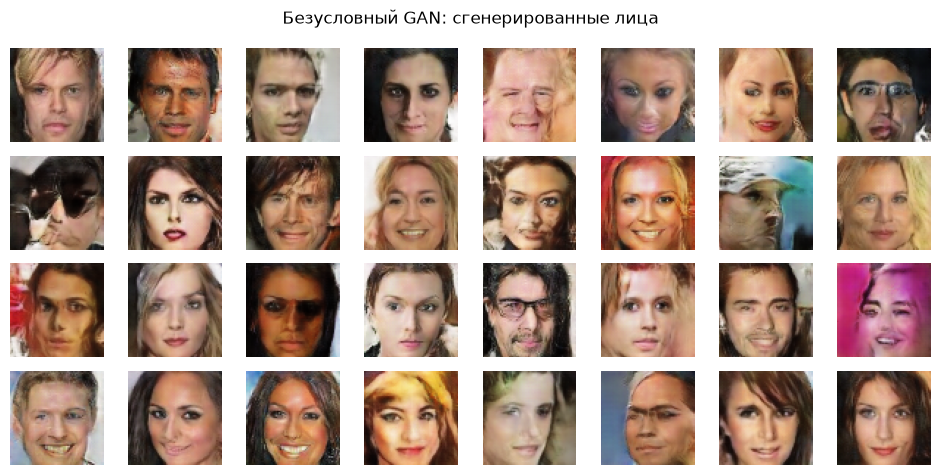

In [9]:
G_uncond, hist_uncond = run_or_load('uncond', num_classes=0, epochs=EPOCHS)

show_grid(generate(G_uncond, 32), 'Безусловный GAN: сгенерированные лица')


## 7. Условная генерация по полу

Берём ту же пару сетей, только с `num_classes=2`. Метка — атрибут `Male` из разметки CelebA.


эпоха   1/25  loss_D=  0.715  loss_G=  5.178


эпоха   2/25  loss_D=  0.681  loss_G=  4.248


эпоха   3/25  loss_D=  0.533  loss_G=  4.659


эпоха   4/25  loss_D=  0.501  loss_G=  4.594


эпоха   5/25  loss_D=  0.514  loss_G=  4.106  FID=  79.9  IS=1.95


...

эпоха  21/25  loss_D=  0.282  loss_G=  4.594


эпоха  22/25  loss_D=  0.262  loss_G=  4.691


эпоха  23/25  loss_D=  0.258  loss_G=  4.747


эпоха  24/25  loss_D=  0.281  loss_G=  4.738


эпоха  25/25  loss_D=  0.243  loss_G=  4.865  FID=  38.2  IS=2.06


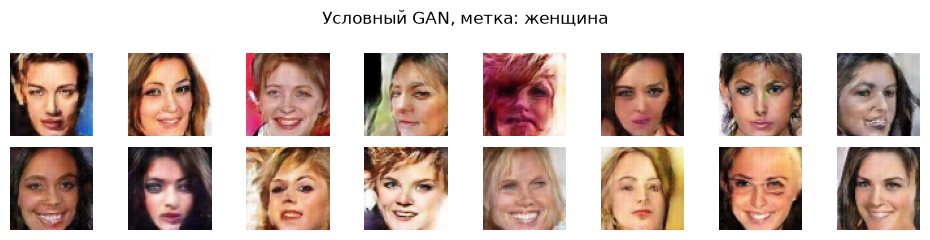

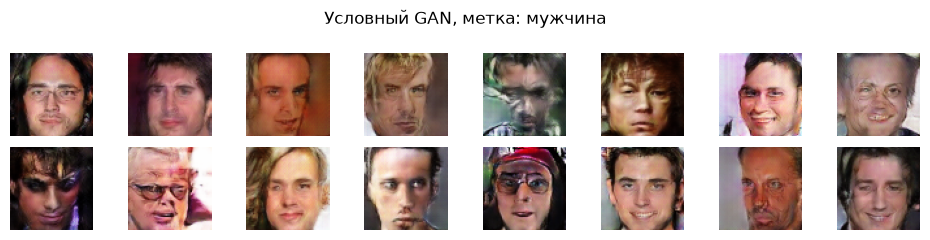

In [10]:
G_cond, hist_cond = run_or_load('cond', num_classes=2, epochs=EPOCHS)

for value, name in ((0, 'женщина'), (1, 'мужчина')):
    show_grid(generate(G_cond, 16, labels=torch.full((16,), value, device=DEVICE)),
              f'Условный GAN, метка: {name}')


## 8. Один вектор шума, разные метки

Если условность работает, то при фиксированном шуме смена метки должна менять пол,
сохраняя общие черты: ракурс, освещение, композицию. Верхний ряд — метка «женщина»,
нижний — тот же самый шум с меткой «мужчина».


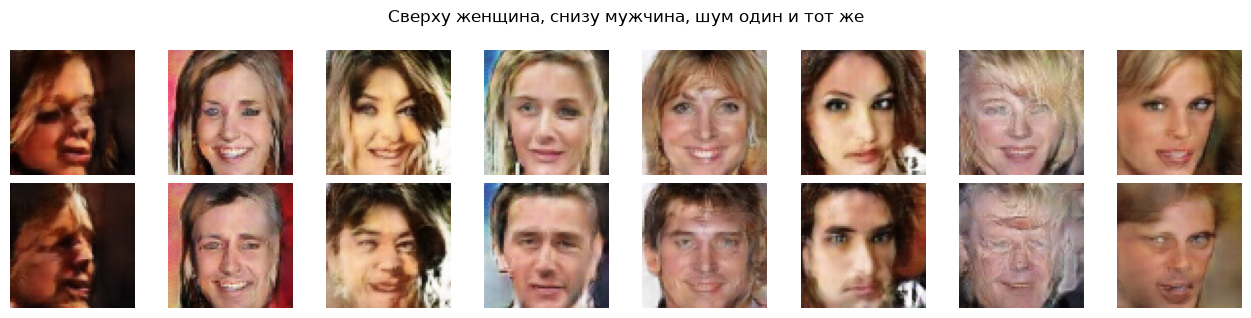

In [11]:
z_fixed = torch.randn(8, NZ, 1, 1, device=DEVICE)

with torch.no_grad():
    G_cond.eval()
    pairs = [G_cond(z_fixed, torch.full((8,), v, device=DEVICE)).cpu() for v in (0, 1)]
    G_cond.train()

show_grid(torch.cat(pairs), 'Сверху женщина, снизу мужчина, шум один и тот же', size=1.6)


## 9. Wasserstein GAN

Обычный GAN оптимизирует расхождение Йенсена–Шеннона, которое перестаёт давать полезный градиент,
когда распределения почти не пересекаются, — отсюда неустойчивость обучения.
WGAN вместо этого оценивает расстояние Вассерштейна, у которого градиент осмысленный всегда.

Дискриминатор превращается в критик: он выдаёт не вероятность, а число, и должен быть
1-липшицевым. В исходном WGAN это обеспечивалось обрезанием весов, но приём грубый;
в WGAN-GP вместо него добавляется штраф за отклонение нормы градиента от единицы.


эпоха   1/25  loss_D= -8.652  loss_G= 20.052


эпоха   2/25  loss_D= -8.826  loss_G= 26.586


эпоха   3/25  loss_D= -7.493  loss_G= 27.602


эпоха   4/25  loss_D= -6.543  loss_G= 28.436


эпоха   5/25  loss_D= -5.806  loss_G= 29.486  FID=  75.7  IS=1.69


...

эпоха  21/25  loss_D= -2.673  loss_G= 47.587


эпоха  22/25  loss_D= -2.622  loss_G= 48.498


эпоха  23/25  loss_D= -2.578  loss_G= 49.145


эпоха  24/25  loss_D= -2.515  loss_G= 49.795


эпоха  25/25  loss_D= -2.473  loss_G= 50.438  FID=  38.4  IS=1.90


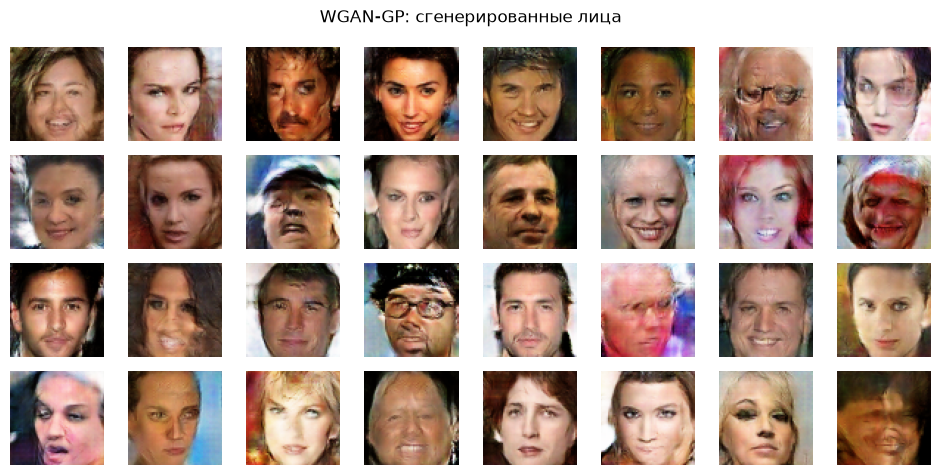

In [12]:
G_wgan, hist_wgan = run_or_load('wgan_gp', num_classes=0, epochs=EPOCHS_WGAN, mode='wgan_gp')

show_grid(generate(G_wgan, 32), 'WGAN-GP: сгенерированные лица')


## 10. Кривые обучения и сравнение


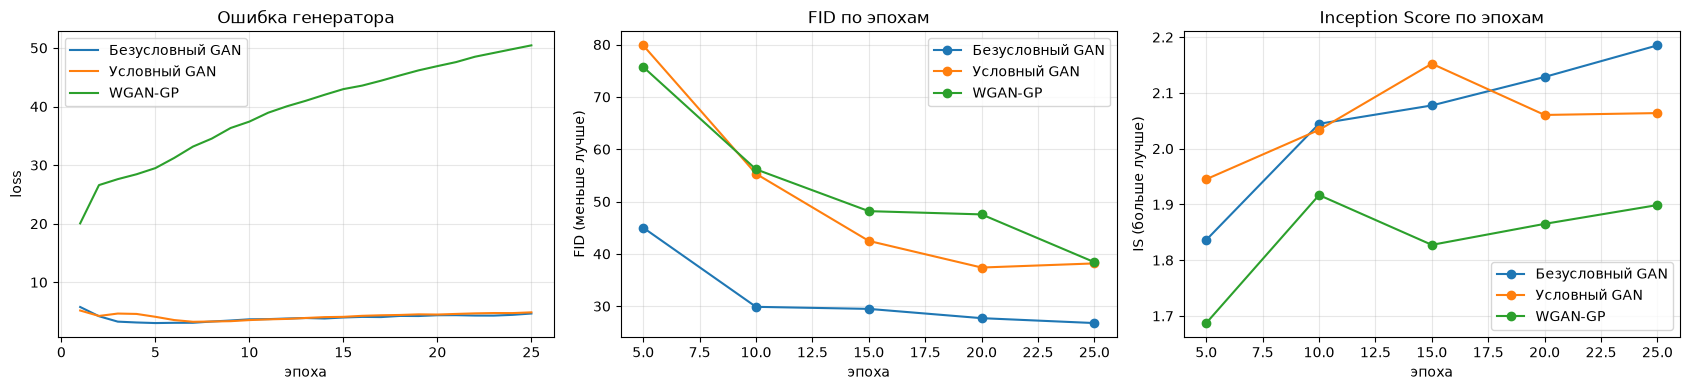

модель                    FID       IS
Безусловный GAN          26.8     2.19
Условный GAN             38.2     2.06
WGAN-GP                  38.4     1.90


In [13]:
runs = {'Безусловный GAN': hist_uncond, 'Условный GAN': hist_cond, 'WGAN-GP': hist_wgan}

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for name, h in runs.items():
    axes[0].plot(range(1, len(h['loss_g']) + 1), h['loss_g'], label=name)
    axes[1].plot(h['eval_epoch'], h['fid'], marker='o', label=name)
    axes[2].plot(h['eval_epoch'], h['is'], marker='o', label=name)

for ax, title, ylabel in zip(axes, ('Ошибка генератора', 'FID по эпохам', 'Inception Score по эпохам'),
                             ('loss', 'FID (меньше лучше)', 'IS (больше лучше)')):
    ax.set_title(title)
    ax.set_xlabel('эпоха')
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

print(f'{"модель":20s} {"FID":>8s} {"IS":>8s}')
for name, h in runs.items():
    print(f'{name:20s} {h["fid"][-1]:8.1f} {h["is"][-1]:8.2f}')


## Выводы

**Данные.** Детектор YuNet нашёл лицо на 202 507 изображениях из 202 599 (99.95%). Каждое лицо
выровнено преобразованием подобия по пяти опорным точкам, так что глаза у всех оказались
в одном месте кадра. Распределение по полу: 41.7% мужчин, 58.3% женщин.

**Обучение.** Три модели по 25 эпох на RTX 4060, вход 64x64, батч 128, 1582 батча в эпохе.
Генератор 3.58M параметров, дискриминатор 2.77M.

| модель | FID | IS |
|---|---|---|
| Безусловный GAN | **26.8** | 2.19 |
| Условный GAN | 38.2 | 2.06 |
| WGAN-GP | 38.4 | 1.90 |

FID безусловной модели падал монотонно все 25 эпох: 45.0 на пятой, 29.9 на десятой, 26.8 на
двадцать пятой. Ни коллапса мод, ни расхождения не случилось. Значение 26.8 для DCGAN на CelebA
в разрешении 64x64 соответствует уровню, который приводят для этой архитектуры в литературе.

**Условная генерация работает.** На картинке с фиксированным вектором шума видно главное:
при смене метки меняется пол, а поза, освещение, фон и общая композиция сохраняются. Значит,
генератор действительно использует метку, а не игнорирует её, подменяя условность случайностью.

Условная модель показала FID хуже безусловной (38.2 против 26.8). Это ожидаемо: задача сложнее,
поскольку выучить нужно не одно распределение лиц, а два согласованных, и при том же числе эпох
на каждое приходится меньше обучения.

**Про WGAN-GP.** Итоговый FID 38.4 хуже, чем у обычного GAN, но сравнение здесь некорректно
по числу обновлений генератора: при `n_critic = 5` генератор за те же 25 эпох получил в пять раз
меньше шагов. По кривой видно, что его FID продолжал заметно снижаться до самого конца
(75.7 → 56.2 → 48.2 → 47.5 → 38.4), тогда как у обычного GAN кривая уже вышла на плато.
При равном числе обновлений генератора результаты были бы ближе.

**Про рост ошибки генератора у WGAN-GP.** На графике его loss растёт от 20 до 50, и это не признак
расхождения. Величина `-E[D(fake)]` ничем не ограничена сверху: критик не выдаёт вероятность,
а оценивает расстояние Вассерштейна, и абсолютный масштаб его выходов свободно дрейфует
по ходу обучения. Следить нужно за ошибкой критика, которая как раз вела себя правильно:
поднималась от -8.7 к -2.5, то есть оценка расстояния между распределениями сокращалась.

**Про Inception Score.** Метрика держится около 1.9–2.2 и почти не меняется, хотя качество
по FID улучшается втрое. Причина в самой метрике: IS оценивает разнообразие по распределению
классов ImageNet, а все наши изображения — лица, для классификатора это один класс. Для генерации
лиц IS малоинформативен, опираться следует на FID.

**Про ошибки генератора и дискриминатора у обычного GAN.** Ошибка дискриминатора снижалась
(0.64 → 0.25), ошибка генератора росла (5.8 → 4.7 с промежуточным минимумом), то есть
дискриминатор постепенно выигрывал. Обучение при этом не развалилось, и FID продолжал падать —
наглядное подтверждение того, что по лоссам обычного GAN о качестве судить нельзя.
